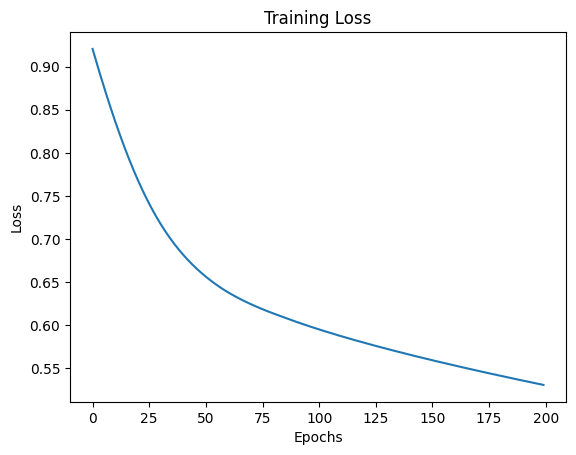

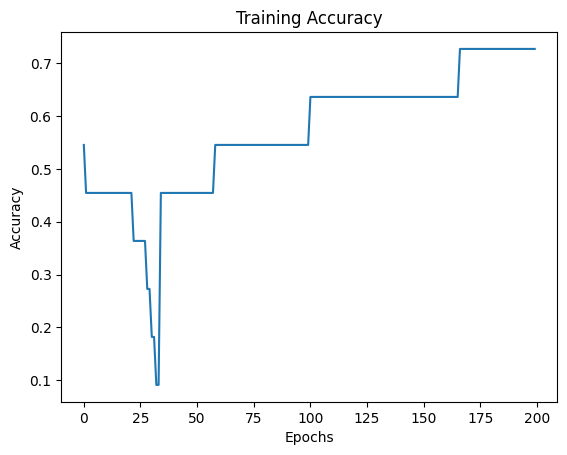

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 54ms/step

Predicted Probabilities:
 [[0.4250867 ]
 [0.4318585 ]
 [0.4821795 ]
 [0.5328646 ]
 [0.58288014]
 [0.63124657]
 [0.6771113 ]
 [0.7198037 ]
 [0.7588615 ]
 [0.79403293]
 [0.8252555 ]]

Final Class Predictions:
 [0 0 0 1 1 1 1 1 1 1 1]

Final Loss: 0.5297742486000061
Final Training Accuracy: 0.7272727489471436


In [11]:
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers

# -------- Dataset --------
X = np.array([[0], [1], [2], [3], [4], [5], [6], [7], [8], [9], [10]], dtype=float)

# Labels (0 or 1)  → NO ONE-HOT NEEDED NOW
Y = np.array([0, 0, 0, 0, 0, 0, 1, 1, 1, 1, 1])

# -------- Build MLP Model --------
model = keras.Sequential([
    layers.Dense(4, activation="relu", input_shape=(1,)),
    layers.Dense(1, activation="sigmoid")   # ONLY ONE OUTPUT NEURON
])

# Compile model (IMPORTANT CHANGE)
model.compile(
    optimizer="adam",
    loss="binary_crossentropy",   # changed
    metrics=["accuracy"]
)

# -------- Train model --------
history = model.fit(X, Y, epochs=200, verbose=0)

# -------- Plot Loss --------
plt.figure()
plt.plot(history.history["loss"])
plt.xlabel("Epochs")
plt.ylabel("Loss")
plt.title("Training Loss")
plt.show()

# -------- Plot Accuracy --------
plt.figure()
plt.plot(history.history["accuracy"])
plt.xlabel("Epochs")
plt.ylabel("Accuracy")
plt.title("Training Accuracy")
plt.show()

# -------- Predictions --------
pred = model.predict(X)

# Convert probabilities to 0/1
final_pred = (pred > 0.5).astype(int)

print("\nPredicted Probabilities:\n", pred)
print("\nFinal Class Predictions:\n", final_pred.flatten())

loss, accuracy = model.evaluate(X, Y, verbose=0)

print("\nFinal Loss:", loss)
print("Final Training Accuracy:", accuracy)